Sources: 

- https://github.com/spatialthoughts/geopython-tutorials/blob/main/notebooks/xarray_climate_trends.ipynb
- https://developers.google.com/earth-engine/datasets/catalog/IDAHO_EPSCOR_TERRACLIMATE#description
- https://developers.google.com/earth-engine/tutorials/community/groundwater-recharge-estimation
- https://developmentseed.org/tensorflow-eo-training-2/docs/Lesson4a_GEE_PythonAPI_TensorFlow_Regression.html
- https://github.com/davemlz/eemont

In [ ]:
import ee
import geemap
import pandas as pd

# Trigger the authentication flow.
ee.Authenticate()

# Initialize the library.
# If you want to run this code, you first need a Google Earth Engine account, then you can use the project ID on GEE website to replace 'my_project'
ee.Initialize(project='my_project')
#  This is Dominik's project ID, only Dominik can run it as he is authenticated with this project ID, but you can run the same code if you create a GEE account
# ee.Initialize(project="phonic-biplane-488409-m3")

In [6]:
dataset = ee.ImageCollection('IDAHO_EPSCOR/TERRACLIMATE').filter(
    ee.Filter.date('1958-01-01', '2017-08-01')
)
maximum_temperature = dataset.select('tmmx')
maximum_temperature_vis = {
    'min': -300.0,
    'max': 300.0,
    'palette': [
        '1a3678',
        '2955bc',
        '5699ff',
        '8dbae9',
        'acd1ff',
        'caebff',
        'e5f9ff',
        'fdffb4',
        'ffe6a2',
        'ffc969',
        'ffa12d',
        'ff7c1f',
        'ca531a',
        'ff0000',
        'ab0000',
    ],
}

m = geemap.Map(basemap='HYBRID')
m.set_center(71.72, 52.48, 3)
m.add_layer(
    maximum_temperature, maximum_temperature_vis, 'Maximum Temperature'
)
m.add_layer(
    maximum_temperature, maximum_temperature_vis, 'Maximum Temperature'
)
m

Map(center=[52.48, 71.72], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [36]:
TARGET_COUNTRY = 'United Kingdom'
start_year = 1950
end_year = 2013

# 2. Get Country Boundary
countries = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017")
region = countries.filter(ee.Filter.eq('country_na', TARGET_COUNTRY))

# 3. Filter Dataset 
# MONTHLY_AGGR gives exactly one image per month (the total monthly mean)
dataset = ee.ImageCollection("ECMWF/ERA5_LAND/MONTHLY_AGGR") \
            .filter(ee.Filter.calendarRange(start_year, end_year, 'year')) \
            .select('temperature_2m')

# 4. Reduction Function
def get_spatial_mean(image):
    date = image.date()
    # Spatial average across the country geometry
    mean_val = image.subtract(273.15).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region.geometry(),
        scale=20000, # Increased scale slightly for faster processing of 60+ years
        maxPixels=1e9
    ).get('temperature_2m')
    
    return ee.Feature(None, {
        'year': date.get('year'),
        'month': date.get('month'),
        'country': TARGET_COUNTRY,
        'avg_temp': mean_val
    })

# 5. Execute and convert to Pandas
print(f"Fetching monthly data for {TARGET_COUNTRY}...")
monthly_stats = dataset.map(get_spatial_mean).getInfo()

# Extract properties
data_list = [feat['properties'] for feat in monthly_stats['features']]
df = pd.DataFrame(data_list)

# Ensure data is sorted chronologically
df = df.sort_values(['year', 'month'])

# Reorder columns: Year, Country, Month, Temp
df = df[['year', 'month', 'country', 'avg_temp']]

# 6. Save to CSV
filename = f"{TARGET_COUNTRY}_monthly_1950_2013.csv"
df.to_csv(filename, index=False, header=False)

print(f"Success! Dataframe has {len(df)} rows.")
print(df.head(12)) # Shows the first full year

Fetching monthly data for United Kingdom...
Success! Dataframe has 767 rows.
    year  month         country   avg_temp
0   1950      2  United Kingdom   3.734223
1   1950      3  United Kingdom   6.172974
2   1950      4  United Kingdom   5.949743
3   1950      5  United Kingdom   9.902712
4   1950      6  United Kingdom  14.329572
5   1950      7  United Kingdom  14.637624
6   1950      8  United Kingdom  14.298915
7   1950      9  United Kingdom  11.652107
8   1950     10  United Kingdom   8.839115
9   1950     11  United Kingdom   4.562092
10  1950     12  United Kingdom   0.274496
11  1951      1  United Kingdom   2.666189


Map(center=[54.02578252225892, -2.7797182104658], controls=(WidgetControl(options=['position', 'transparent_bg…

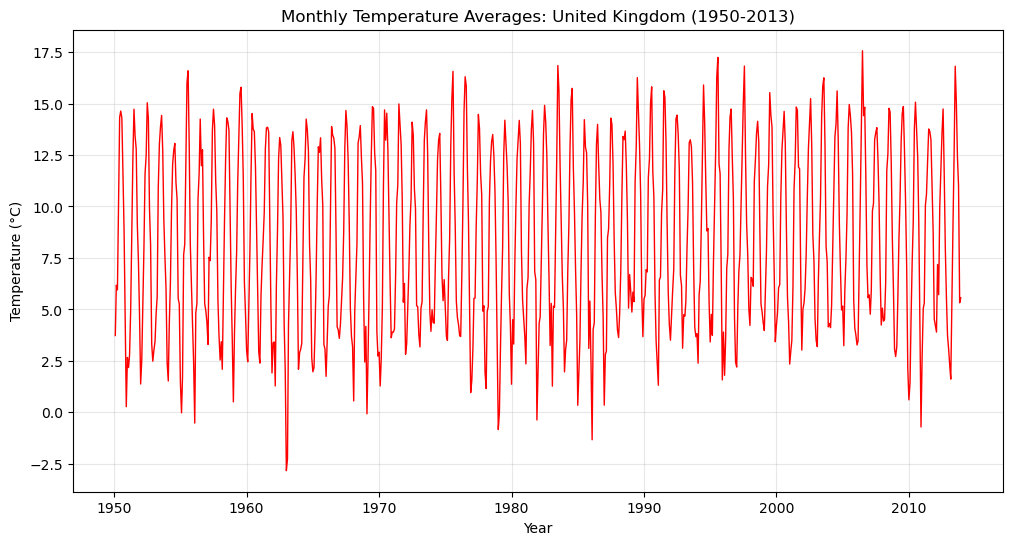

In [37]:
import matplotlib.pyplot as plt

# 5. Create Map
Map = geemap.Map()
vis_params = {'min': 268, 'max': 293, 'palette': ['#0000ff', '#00ffff', '#ffff00', '#ff0000']}

first_month = dataset.first().clip(region)
Map.centerObject(region, 6)
Map.addLayer(first_month, vis_params, 'Jan 1950 Temp (K)')
Map.addLayer(region, {'color': 'black', 'fillColor': '00000000'}, 'Germany Border')
display(Map)

# 6. Create the Chart using the Pandas DataFrame
plt.figure(figsize=(12, 6))
# Create a date column for better plotting
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))

plt.plot(df['date'], df['avg_temp'], color='red', linewidth=1)
plt.title(f'Monthly Temperature Averages: {TARGET_COUNTRY} ({start_year}-{end_year})')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.show()


Descriptive Statistics for Germany (1950-2013):
count    767.000000
mean       8.586870
std        6.668627
min      -10.240659
25%        3.068828
50%        8.466007
75%       14.642444
max       22.339257
Name: avg_temp, dtype: float64

Calculated Trend: 0.203 °C increase per decade


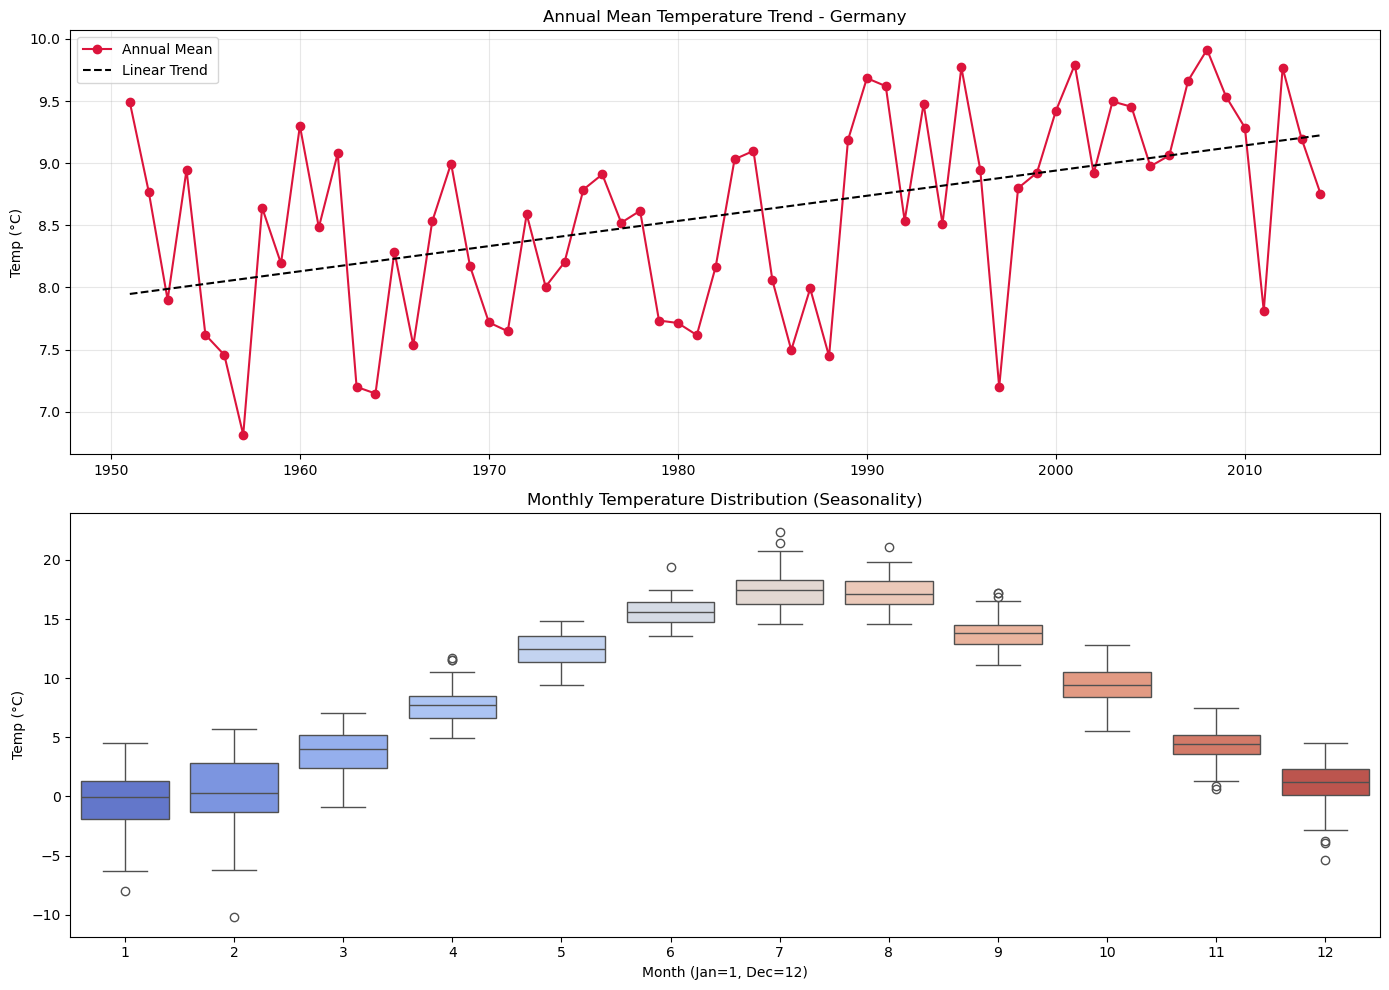

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load your saved CSV
# Ensure the column names match what we saved earlier
df = pd.read_csv('Germany_monthly_1950_2013.csv', header=None, names=['year', 'month', 'country', 'avg_temp'])

# 2. Setup a DateTime index for time-series analysis
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
df.set_index('date', inplace=True)

# --- STATISTICAL ANALYSIS ---

# Calculate basic descriptive statistics
stats = df['avg_temp'].describe()
print("Descriptive Statistics for Germany (1950-2013):")
print(stats)

# Calculate the warming trend (Linear Regression)
from scipy import stats as scipy_stats
slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(df['year'], df['avg_temp'])
print(f"\nCalculated Trend: {slope * 10:.3f} °C increase per decade")

# --- VISUALISATION ---

plt.figure(figsize=(14, 10))

# Graph A: Annual Average Trend
annual_mean = df['avg_temp'].resample('YE').mean()
plt.subplot(2, 1, 1)
plt.plot(annual_mean.index, annual_mean, marker='o', color='crimson', label='Annual Mean')
plt.title('Annual Mean Temperature Trend - Germany')
plt.ylabel('Temp (°C)')
plt.grid(True, alpha=0.3)
# Add a trendline
plt.plot(annual_mean.index, intercept + slope * annual_mean.index.year, color='black', linestyle='--', label='Linear Trend')
plt.legend()

# Graph B: Seasonal Variability (Boxplot)
plt.subplot(2, 1, 2)
sns.boxplot(x='month', y='avg_temp', data=df.reset_index(), palette='coolwarm')
plt.title('Monthly Temperature Distribution (Seasonality)')
plt.xlabel('Month (Jan=1, Dec=12)')
plt.ylabel('Temp (°C)')

plt.tight_layout()
plt.show()


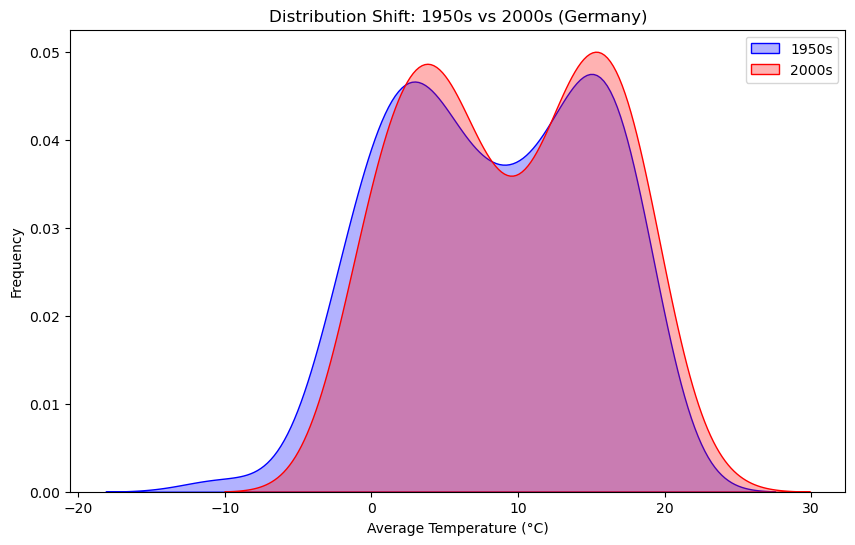

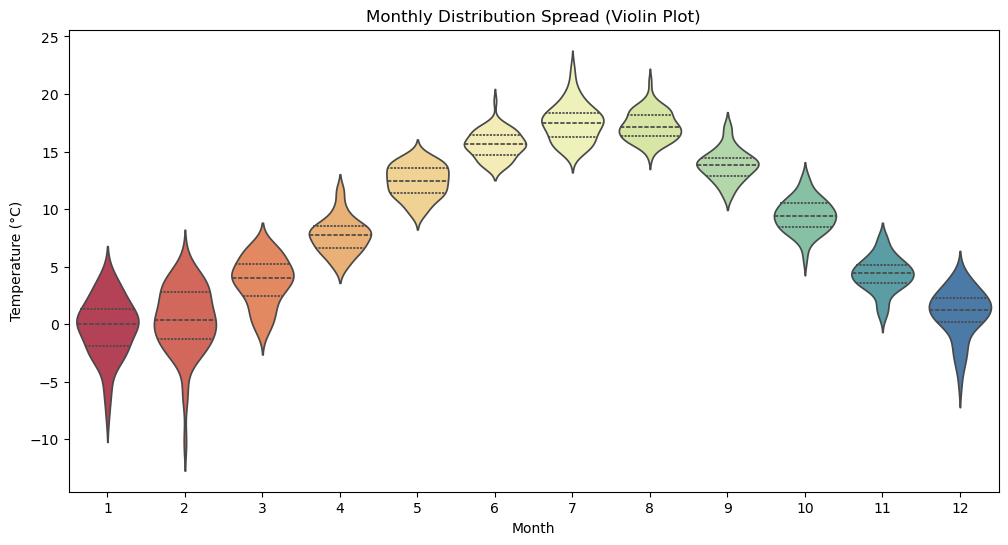

Distribution Metrics by Decade:
            mean       std      skew  kurtosis
decade                                        
1950    8.303811  6.841441 -0.142114 -1.045708
1960    8.114970  6.880868 -0.261133 -1.169444
1970    8.273019  6.385447  0.010606 -1.250755
1980    8.377724  6.722100 -0.190706 -1.086714
1990    8.920834  6.503029  0.031475 -1.197160
2000    9.409997  6.578971 -0.015449 -1.300903
2010    8.883139  7.059916 -0.129027 -1.182701


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a "Decade" column for grouping
df['decade'] = (df['year'] // 10) * 10

# --- ANGLE 1: The Decade Shift (Density Plot) ---
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['decade'] == 1950], x='avg_temp', label='1950s', fill=True, color="blue", alpha=0.3)
sns.kdeplot(data=df[df['decade'] == 2000], x='avg_temp', label='2000s', fill=True, color="red", alpha=0.3)
plt.title('Distribution Shift: 1950s vs 2000s (Germany)')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# --- ANGLE 2: Monthly Variance (Ridge-style Boxplot) ---
plt.figure(figsize=(12, 6))
sns.violinplot(x='month', y='avg_temp', data=df, inner="quart", palette="Spectral")
plt.title('Monthly Distribution Spread (Violin Plot)')
plt.ylabel('Temperature (°C)')
plt.xlabel('Month')
plt.show()

# --- ANGLE 3: Statistical Moments ---
print("Distribution Metrics by Decade:")
# We use .apply(lambda x: ...) to ensure all stats are calculated correctly 
# regardless of your Pandas version.
pivot_stats = df.groupby('decade')['avg_temp'].apply(lambda x: pd.Series({
    'mean': x.mean(),
    'std': x.std(),
    'skew': x.skew(),
    'kurtosis': x.kurtosis()
})).unstack()
print(pivot_stats)
